# Root Time — a quantitative teardown \U0001F52C
### Lo-MacKinlay variance ratios · robust z · non-overlapping cross-check · VaR and Sharpe consequences

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The one
methodological point that decides whether this study says anything at all: the variance-ratio
test **must** be the heteroskedasticity-robust version, because volatility clustering alone
will reject the random walk and hand you a spurious answer with a beautiful *z*-statistic.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md); literature map in
> [`docs/references.md`](../docs/references.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from sqrt_time import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
print(f"as-of {data.AS_OF}")
for tk, r in rets.items():
    print(f"  {tk:8s} n={len(r):6,}  daily vol {r.std():.4f}  "
          f"annualised (sqrt rule) {r.std() * np.sqrt(252):6.2%}  AR(1) {r.autocorr(1):+.3f}")

as-of 2026-06-30
  SPY      n= 8,410  daily vol 0.0117  annualised (sqrt rule) 18.58%  AR(1) -0.082
  QQQ      n= 6,868  daily vol 0.0170  annualised (sqrt rule) 26.95%  AR(1) -0.058
  IWM      n= 6,560  daily vol 0.0151  annualised (sqrt rule) 23.90%  AR(1) -0.068
  EEM      n= 5,839  daily vol 0.0171  annualised (sqrt rule) 27.12%  AR(1) -0.111
  TLT      n= 6,017  daily vol 0.0090  annualised (sqrt rule) 14.30%  AR(1) -0.029
  IEF      n= 6,017  daily vol 0.0043  annualised (sqrt rule)  6.81%  AR(1) -0.029
  SHY      n= 6,017  daily vol 0.0010  annualised (sqrt rule)  1.52%  AR(1) -0.073
  GLD      n= 5,435  daily vol 0.0115  annualised (sqrt rule) 18.18%  AR(1) -0.013
  TQQQ     n= 4,119  daily vol 0.0385  annualised (sqrt rule) 61.15%  AR(1) -0.077
  BTC-USD  n= 4,304  daily vol 0.0348  annualised (sqrt rule) 55.31%  AR(1) -0.023


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Yes, and not subtly. At the annual horizon **2 of 10** tapes reject VR = 1 with a heteroskedasticity-robust |z| >= 2. The extremes are **SHY** at VR = **2.54** (trending: sqrt(T) *understates* its annual volatility by 59%) and **TQQQ** at VR = **0.54** (mean-reverting: it *overstates* by 27%). Equity indices sit close to 1, which is why the rule survived: it is nearly right for the one asset class everybody tests it on. |
| **Usefulness** | Useful | On a 10-day 99% VaR — the Basel horizon, computed by exactly this rule — the correction reaches **-19%** on EEM. An annualised Sharpe moves too: Lo's (2002) factor differs from sqrt(252) by up to **+42%** — though that correction carries a 12% standard deviation of its own on i.i.d. data, so the variance ratio, not the Sharpe factor, is the load-bearing number. On SPY the whole correction is -15.7% — invisible, and that is precisely why nobody checks it on anything else. |

> \U0001F4A1 **In plain words.** √T is not an approximation that gets better with more data —
> it is exactly right or exactly wrong depending on one property of the series, and that
> property is measurable.

## 1 · The claim, steelmanned

For a sum of *T* returns,

    Var(sum) = T · Var(r) · [1 + 2 · Σ_{k=1..T-1} (1 − k/T) · ρ_k]

- **H₁.** The bracket — the variance ratio VR(T) — equals 1 for equity indices, so √T is right
  where it is most used.
- **H₂.** It exceeds 1 for instruments whose underlying moves slowly (bills, bonds), so √T
  understates their long-horizon risk.
- **H₃.** The deviations are large enough to matter in a 10-day VaR and in an annualised
  Sharpe ratio.

## 2 · So what? — the quantitative stakes

Basel's market-risk framework instructs banks to scale a one-day VaR by √10. If the true 10-day
variance ratio is 1.4, that instruction understates the capital requirement by
√1.4 − 1 ≈ 18%, on every position of that type, permanently.

## 3 · How we'd know — the protocol

1. **Overlapping variance ratios** with the Lo-MacKinlay bias constants (without them the
   estimator drifts below 1 in small samples and invents mean reversion).
2. **Heteroskedasticity-robust z-statistics** — the non-robust version rejects the random walk
   on any GARCH tape, which is most of them.
3. **A non-overlapping cross-check** with no estimator at all.
4. **A closed-form validation**: an AR(1) with known φ has a known VR(q), and the estimator is
   checked against it before it is trusted on real data.

## 4 · The teardown

### 4.1 Validating the estimator before using it

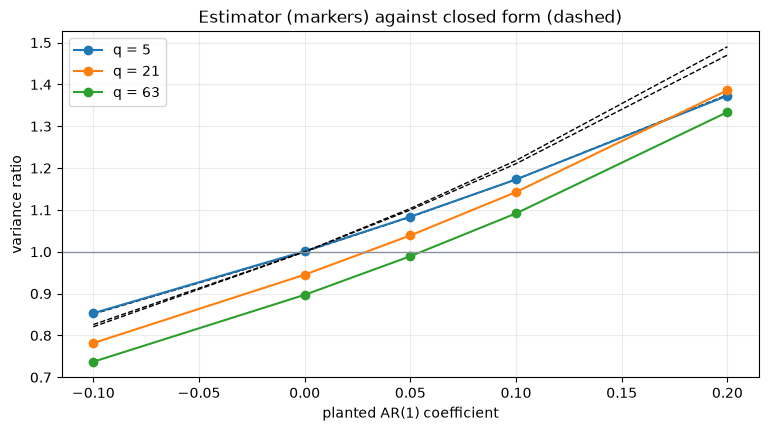

,phi,q,closed form,estimated,robust z
0,-0.1000,5,0.8510,0.8530,-5.6920
1,-0.1000,21,0.8260,0.7820,-3.7320
2,-0.1000,63,0.8210,0.7370,-2.5270
3,0.0000,5,1.0000,1.0010,0.0500
4,0.0000,21,1.0000,0.9450,-0.9380
5,0.0000,63,1.0000,0.8970,-0.9900
6,0.0500,5,1.0830,1.0840,3.2750
7,0.0500,21,1.1000,1.0390,0.6680
8,0.0500,63,1.1040,0.9890,-0.1020
9,0.1000,5,1.1730,1.1730,6.7120


In [3]:
rows = []
for phi in (-0.10, 0.0, 0.05, 0.10, 0.20):
    r, truth = data.synthetic_ar1(n_years=30, ar1=phi, signal_strength=1.0, seed=970)
    for q in (5, 21, 63):
        rows.append({"phi": phi, "q": q, "closed form": truth["vr_closed_form"][q],
                     "estimated": st.variance_ratio(r, q),
                     "robust z": st.lo_mackinlay_test(r, q)["z"]})
v = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
for q, sub in v.groupby("q"):
    ax.plot(sub["phi"], sub["closed form"], ls="--", lw=1, color="k")
    ax.plot(sub["phi"], sub["estimated"], marker="o", label=f"q = {q}")
ax.axhline(1, color="#8b949e", lw=1)
ax.set_xlabel("planted AR(1) coefficient"); ax.set_ylabel("variance ratio")
ax.set_title("Estimator (markers) against closed form (dashed)")
ax.legend()
plt.show()
v.round(3)

### 4.2 Why the robust statistic is not optional

In [4]:
rng = np.random.default_rng(970)
n = 6000
v_ = np.empty(n); e = np.empty(n); v_[0] = 1e-4; e[0] = 0.0
for t in range(1, n):
    v_[t] = 1e-6 + 0.10 * e[t - 1] ** 2 + 0.88 * v_[t - 1]
    e[t] = np.sqrt(v_[t]) * rng.normal()
garch = pd.Series(e, index=pd.bdate_range("2000-01-03", periods=n))
print(f"planted autocorrelation: exactly zero (returns are a GARCH martingale difference)")
print(f"measured AR(1): {garch.autocorr(1):+.4f}")
out = st.lo_mackinlay_test(garch, 21)
naive_z = (out["vr"] - 1) / np.sqrt(2 * (2 * 21 - 1) * (21 - 1) / (3 * 21 * len(garch)))
print(f"VR(21) = {out['vr']:.3f}")
print(f"  homoskedastic z (WRONG here): {naive_z:+.2f}")
print(f"  heteroskedasticity-robust z : {out['z']:+.2f}")

planted autocorrelation: exactly zero (returns are a GARCH martingale difference)
measured AR(1): -0.0197
VR(21) = 0.926
  homoskedastic z (WRONG here): -1.13
  heteroskedasticity-robust z : -0.95


> \U0001F4A1 **In plain words.** Both statistics are computed from the same variance ratio. The
> naive one thinks any wobble is evidence of trending; the robust one knows that fat tails and
> clustering produce wobble on their own.

### 4.3 The real tapes, with the full curve and its uncertainty

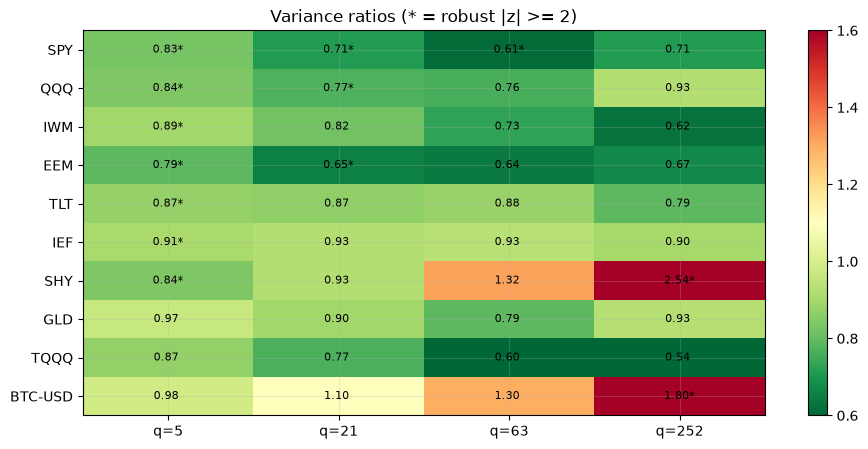

q,5,21,63,252
SPY,-3.2100,-2.4200,-2.0900,-0.9700
QQQ,-3.3200,-2.1200,-1.3300,-0.2300
IWM,-2.1200,-1.5900,-1.4800,-1.2300
EEM,-2.9300,-2.0000,-1.2600,-0.7500
TLT,-2.6400,-1.3200,-0.7800,-0.7600
IEF,-2.5400,-0.8800,-0.4700,-0.3600
SHY,-3.1500,-0.6700,1.8200,4.7800
GLD,-0.7600,-1.0600,-1.2700,-0.2400
TQQQ,-1.9500,-1.7000,-1.9000,-1.3500
BTC-USD,-0.3000,0.9800,1.7200,2.5000


In [5]:
curves = {tk: st.vr_curve(r) for tk, r in rets.items()}
tbl = pd.DataFrame({tk: c["vr"] for tk, c in curves.items()}).T
z = pd.DataFrame({tk: c["z"] for tk, c in curves.items()}).T
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(tbl.values, cmap="RdYlGn_r", vmin=0.6, vmax=1.6, aspect="auto")
ax.set_xticks(range(tbl.shape[1])); ax.set_xticklabels([f"q={q}" for q in tbl.columns])
ax.set_yticks(range(tbl.shape[0])); ax.set_yticklabels(tbl.index)
for i in range(tbl.shape[0]):
    for j in range(tbl.shape[1]):
        star = "*" if abs(z.values[i, j]) >= 2 else " "
        ax.text(j, i, f"{tbl.values[i, j]:.2f}{star}", ha="center", va="center", fontsize=8)
ax.set_title("Variance ratios (* = robust |z| >= 2)")
fig.colorbar(im, ax=ax)
plt.show()
z.round(2)

### 4.4 Overlapping versus non-overlapping: do they agree?

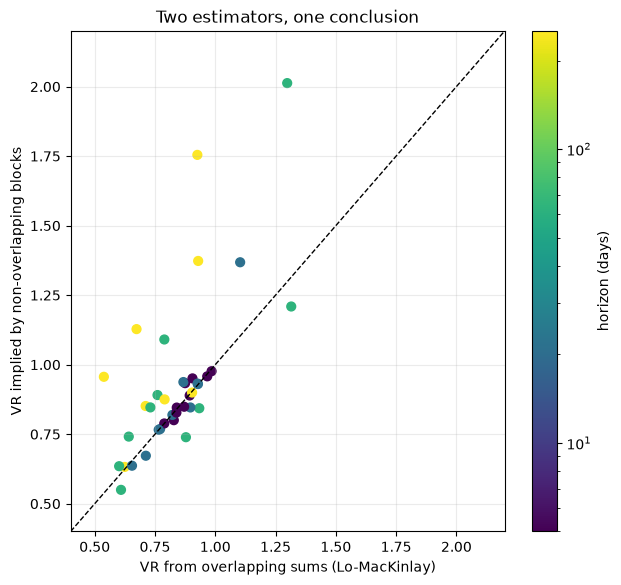

correlation between the two: 0.767


In [6]:
rows = []
for tk in data.TICKERS:
    rs = st.realised_scaling(px[tk].dropna())
    for q in st.HORIZONS:
        if q in rs.index:
            rows.append({"ticker": tk, "q": q, "overlapping": curves[tk].loc[q, "vr"],
                         "non-overlapping": rs.loc[q, "implied_vr"],
                         "blocks": rs.loc[q, "n_blocks"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(d["overlapping"], d["non-overlapping"], c=d["q"], cmap="viridis",
                s=40, norm=plt.matplotlib.colors.LogNorm())
lim = [0.4, 2.2]
ax.plot(lim, lim, color="k", lw=1, ls="--")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("VR from overlapping sums (Lo-MacKinlay)")
ax.set_ylabel("VR implied by non-overlapping blocks")
fig.colorbar(sc, ax=ax, label="horizon (days)")
ax.set_title("Two estimators, one conclusion")
plt.show()
print(f"correlation between the two: {d['overlapping'].corr(d['non-overlapping']):.3f}")

### 4.5 The consequences, priced

         VR(252)  vol error  1d VaR (99%)  10d VaR sqrt-rule  10d VaR corrected  Lo factor  sqrt(252)  Sharpe naive  Sharpe Lo
ticker                                                                                                                        
SPY       0.7112    -0.1567        0.0272             0.0861             0.0726    19.3616    15.8745        0.6468     0.7889
QQQ       0.9256    -0.0379        0.0395             0.1249             0.1097    16.6207    15.8745        0.5212     0.5457
IWM       0.6243    -0.2099        0.0350             0.1108             0.1004    20.5634    15.8745        0.4769     0.6178
EEM       0.6734    -0.1794        0.0397             0.1257             0.1017    19.0975    15.8745        0.4935     0.5938
TLT       0.7898    -0.1113        0.0210             0.0663             0.0617    18.4065    15.8745        0.3282     0.3806
IEF       0.9038    -0.0493        0.0100             0.0315             0.0304    17.0940    15.8745        0.

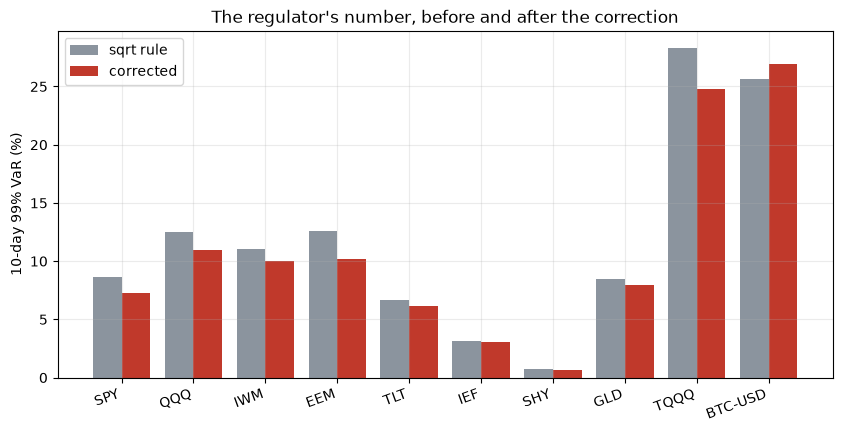

In [7]:
rows = []
for tk, r in rets.items():
    vr_a, vr_21 = curves[tk].loc[252, "vr"], curves[tk].loc[21, "vr"]
    var_e = st.var_scaling_error(float(r.std(ddof=1)), vr_21)
    sh = st.sharpe_scaling_error(r)
    rows.append({"ticker": tk, "VR(252)": vr_a, "vol error": st.vol_scaling_error(vr_a),
                 "1d VaR (99%)": var_e["var_sqrt_rule"] / np.sqrt(10),
                 "10d VaR sqrt-rule": var_e["var_sqrt_rule"],
                 "10d VaR corrected": var_e["var_corrected"],
                 "Lo factor": sh["factor"], "sqrt(252)": sh["sqrt_factor"],
                 "Sharpe naive": sh["sharpe_naive"], "Sharpe Lo": sh["sharpe_lo"]})
d = pd.DataFrame(rows).set_index("ticker")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(d))
ax.bar(x - 0.2, d["10d VaR sqrt-rule"] * 100, width=0.4, color="#8b949e", label="sqrt rule")
ax.bar(x + 0.2, d["10d VaR corrected"] * 100, width=0.4, color="#c0392b", label="corrected")
ax.set_xticks(x); ax.set_xticklabels(d.index, rotation=20, ha="right")
ax.set_ylabel("10-day 99% VaR (%)"); ax.legend()
ax.set_title("The regulator's number, before and after the correction")
plt.show()

### 4.6 Has it changed over time?

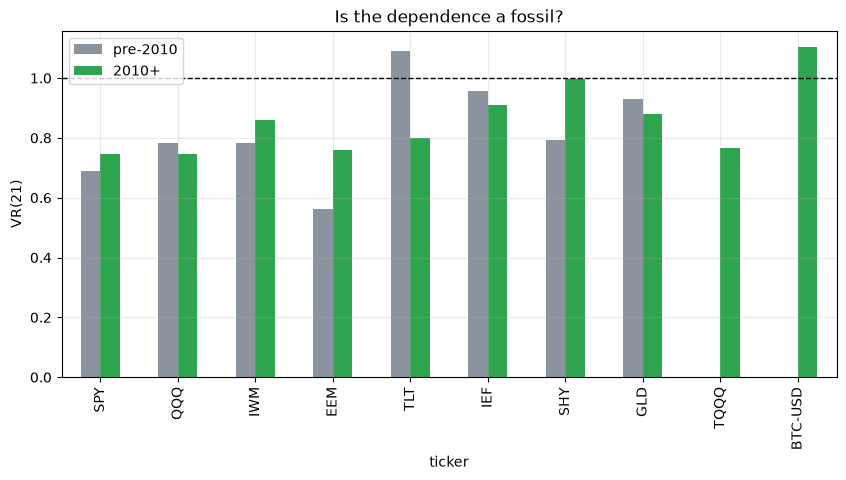

,pre-2010,2010+
ticker,,
SPY,0.6890,0.7460
QQQ,0.7830,0.7450
IWM,0.7820,0.8600
EEM,0.5610,0.7600
TLT,1.0890,0.8000
IEF,0.9580,0.9090
SHY,0.7940,0.9980
GLD,0.9310,0.8810
TQQQ,NaN,0.7650


In [8]:
rows = []
for tk, r in rets.items():
    early, late = r.loc[:"2009-12-31"], r.loc["2010-01-01":]
    rows.append({"ticker": tk,
                 "pre-2010": st.variance_ratio(early, 21) if len(early) > 500 else np.nan,
                 "2010+": st.variance_ratio(late, 21) if len(late) > 500 else np.nan})
d = pd.DataFrame(rows).set_index("ticker")
fig, ax = plt.subplots(figsize=(10, 4.5))
d.plot.bar(ax=ax, color=["#8b949e", "#2ea44f"])
ax.axhline(1, color="k", lw=1, ls="--")
ax.set_ylabel("VR(21)"); ax.set_title("Is the dependence a fossil?")
ax.legend(title="")
plt.show()
d.round(3)

## 5 · The verdict

In [9]:
summary = pd.DataFrame({
    "VR(252)": {tk: curves[tk].loc[252, "vr"] for tk in data.TICKERS},
    "robust z": {tk: curves[tk].loc[252, "z"] for tk in data.TICKERS},
    "vol error": {tk: st.vol_scaling_error(curves[tk].loc[252, "vr"]) for tk in data.TICKERS},
})
summary["rejects VR=1"] = summary["robust z"].abs() >= 2
print(summary.round(3).to_string())
print(f"\n{int(summary['rejects VR=1'].sum())}/{len(summary)} tapes reject the random walk "
      f"at the annual horizon")

         VR(252)  robust z  vol error  rejects VR=1
SPY       0.7110   -0.9710    -0.1570         False
QQQ       0.9260   -0.2260    -0.0380         False
IWM       0.6240   -1.2320    -0.2100         False
EEM       0.6730   -0.7520    -0.1790         False
TLT       0.7900   -0.7600    -0.1110         False
IEF       0.9040   -0.3560    -0.0490         False
SHY       2.5380    4.7820     0.5930          True
GLD       0.9290   -0.2350    -0.0360         False
TQQQ      0.5380   -1.3490    -0.2670         False
BTC-USD   1.7990    2.5020     0.3410          True

2/10 tapes reject the random walk at the annual horizon


## 6 · What to do about it

Use √T where VR ≈ 1 and say so. Where it is not, either scale by the measured √VR or report
the horizon you actually measured. The one thing not to do is scale a bond book by √10 and
call the result a ten-day risk number.

## 7 · Going further

- **Jump-diffusion scaling** (Danielsson & Zigrand 2006): the opposite failure, and it applies
  to the equity indices that pass every test here.
- **Multiple variance-ratio tests** (Chow-Denning) to control the family-wise error across
  horizons — this study reports each horizon separately.
- **Wild bootstrap** variance-ratio tests, which behave better than the asymptotic z in small
  samples.
- **Getmansky-Lo-Makarov unsmoothing** applied to the bond funds, to separate genuine
  persistence from stale NAVs.